In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import  plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import het_arch
import matplotlib.pyplot as plt
from datetime import datetime as dt
import requests
import pytz

In [2]:
path = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=01/01/2010&dataFinal=01/01/2020'
resposta = requests.get(path)
resposta.raise_for_status()

dados = pd.DataFrame(resposta.json())

dados

,data,valor
0,04/01/2010,1.7240
1,05/01/2010,1.7227
2,06/01/2010,1.7337
3,07/01/2010,1.7413
4,08/01/2010,1.7390
...,...,...
2507,24/12/2019,4.0813
2508,26/12/2019,4.0601
2509,27/12/2019,4.0545
2510,30/12/2019,4.0307


In [3]:
# importando série PTAX Venda do site do Banco Central do Brasil
path_2 = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=02/01/2020&dataFinal=31/03/2026'
resposta = requests.get(path_2)
resposta.raise_for_status()

dados_2 = pd.DataFrame(resposta.json())

dados_2

,data,valor
0,02/01/2020,4.0213
1,03/01/2020,4.0522
2,06/01/2020,4.0554
3,07/01/2020,4.0841
4,08/01/2020,4.0672
...,...,...
1563,25/03/2026,5.2275
1564,26/03/2026,5.2308
1565,27/03/2026,5.2376
1566,30/03/2026,5.2353


In [4]:
# juntando as duas séries, dado que o site do Banco Central do Brasil só permite importar um limite máximo de 10 anos
cambio = pd.concat([dados, dados_2])
cambio


,data,valor
0,04/01/2010,1.7240
1,05/01/2010,1.7227
2,06/01/2010,1.7337
3,07/01/2010,1.7413
4,08/01/2010,1.7390
...,...,...
1563,25/03/2026,5.2275
1564,26/03/2026,5.2308
1565,27/03/2026,5.2376
1566,30/03/2026,5.2353


In [11]:
# após tratar a série de câmbio e Receitas Líquidas pelo Excel, estou importando as mesmas 
df = pd.read_excel("Receita_e_cambio.xlsx")
df

,[mil BRL],Receitas Líquidas,cambio
0,1T2010,407566,1.7810
1,2T2010,467367,1.8015
2,3T2010,520915,1.6942
3,4T2010,475679,1.6662
4,1T2011,510663,1.6287
...,...,...,...
59,4T2024,2493426,6.1923
60,1T2025,2483044,5.7422
61,2T2025,2627369,5.4571
62,3T2025,2399201,5.3186


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   [mil BRL]          64 non-null     str    
 1   Receitas Líquidas  64 non-null     int64  
 2   cambio             64 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.0 KB


In [13]:
df["Receitas Líquidas"] = df["Receitas Líquidas"] * 1000
df

,[mil BRL],Receitas Líquidas,cambio
0,1T2010,407566000,1.7810
1,2T2010,467367000,1.8015
2,3T2010,520915000,1.6942
3,4T2010,475679000,1.6662
4,1T2011,510663000,1.6287
...,...,...,...
59,4T2024,2493426000,6.1923
60,1T2025,2483044000,5.7422
61,2T2025,2627369000,5.4571
62,3T2025,2399201000,5.3186


In [14]:
df = df.rename(columns={"[mil BRL]": "data"})
df["data"] = df["data"].astype("str")
df["data"] = df["data"].str.replace(r"(\d)T(\d{4})", r"\2Q\1", regex=True)
df["data"] = pd.PeriodIndex(df["data"], freq="Q")
df = df.set_index("data")
df

,Receitas Líquidas,cambio
data,,
2010Q1,407566000,1.7810
2010Q2,467367000,1.8015
2010Q3,520915000,1.6942
2010Q4,475679000,1.6662
2011Q1,510663000,1.6287
...,...,...
2024Q4,2493426000,6.1923
2025Q1,2483044000,5.7422
2025Q2,2627369000,5.4571


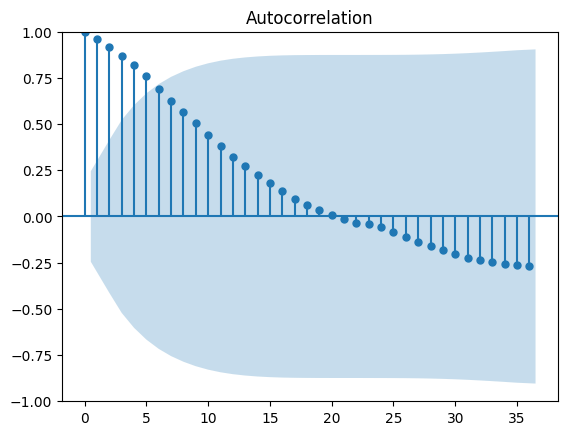

In [15]:
plot_acf(df['Receitas Líquidas'], lags=36)
plt.show()

In [16]:
acf_values = acf(df['Receitas Líquidas'], nlags=36)
acf_values

array([ 1.        ,  0.96148963,  0.91876065,  0.86978388,  0.82107566,
        0.76059756,  0.69191943,  0.62586229,  0.56722403,  0.5043827 ,
        0.44333377,  0.38186186,  0.32447727,  0.27266367,  0.22626487,
        0.18187701,  0.13562496,  0.09608284,  0.06295434,  0.03640438,
        0.00682726, -0.01448255, -0.03350764, -0.0410426 , -0.0576348 ,
       -0.08165862, -0.10879009, -0.13634458, -0.15956367, -0.1821542 ,
       -0.20523369, -0.22425586, -0.2381717 , -0.2475701 , -0.25658589,
       -0.2615627 , -0.26643697])

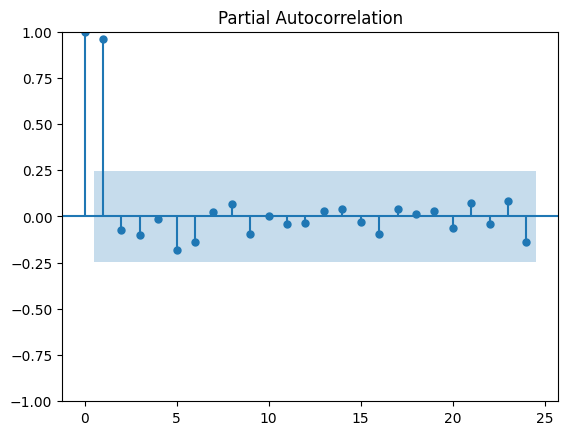

In [17]:
plot_pacf(df['Receitas Líquidas'], lags=24)
plt.show()

In [18]:
resultado = adfuller(df['Receitas Líquidas'].dropna())
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -0.8691418397965983
p-value: 0.7979645603741954
Número de lags usados: 0
Número de observações: 63

Valores Críticos:
1%: -3.5386953618719676
5%: -2.9086446751210775
10%: -2.591896782564878


In [19]:
resultado = kpss(df['Receitas Líquidas'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado[0])
print('p-value:', resultado[1])
print('Lags usados:', resultado[2])
print('\nValores críticos:')
for chave, valor in resultado[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.9843564964534367
p-value: 0.01
Lags usados: 5

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_165988\4092631449.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado = kpss(df['Receitas Líquidas'].dropna(), regression= 'c')


Tanto pelos correlogramas (ACF e PACF), quanto pelos testes ADF e KPSS vemos que a série das Receitas Líquidas da empresa Tupy S.A. não é estacionária. Logo, precisamos diferenciá-la uma vez e, na sequência, testar, uma vez mais, sua estacionariedade. Agora, para a série diferenciada uma vez.

In [20]:
serie_diff = df['Receitas Líquidas'].diff().dropna()
serie_diff

data
2010Q2     59801000.0
2010Q3     53548000.0
2010Q4    -45236000.0
2011Q1     34984000.0
2011Q2     26345000.0
             ...     
2024Q4   -274893000.0
2025Q1    -10382000.0
2025Q2    144325000.0
2025Q3   -228168000.0
2025Q4   -215867000.0
Freq: Q-DEC, Name: Receitas Líquidas, Length: 63, dtype: float64

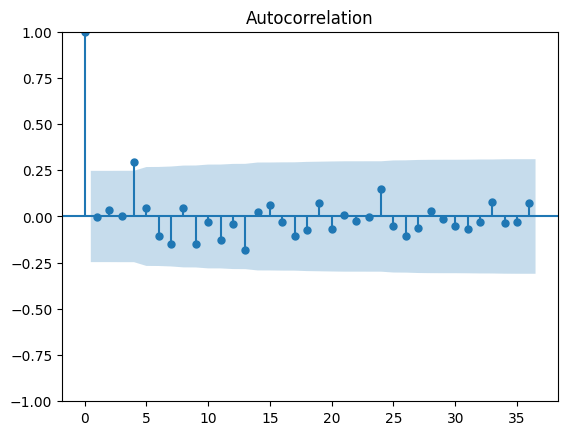

In [21]:
plot_acf(serie_diff, lags=36)
plt.show()

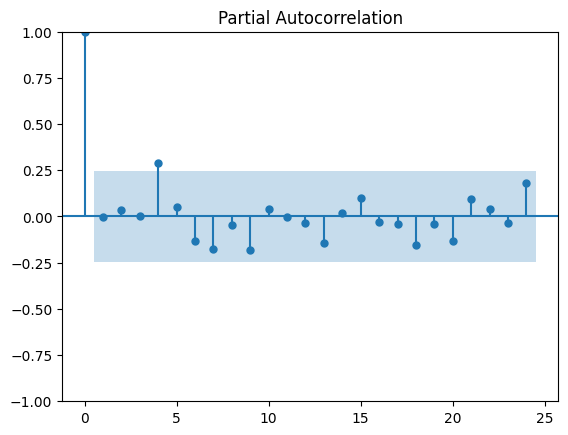

In [22]:
plot_pacf(serie_diff, lags=24)
plt.show()

O pico elevado no lag 4, tanto na série diferenciada das Receitas Líquidas pelos correlogramas ACF e PACF, é sugestivo de sazonalidade. Pode-se testar uma modelo SARIMA (0,1,1,)(0,1,1,4), Assim como pode-se testar um modelo ARIMA (0,1,1). outra possibilidade é testar o modelo com 1 AR e 1 MA, no padrão SARIMA(1,1,1)(0,0,1,4). Também iremos testar a presença da variável exógena 'cambio'.

In [23]:
resultado = adfuller(serie_diff)
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -7.61622318968422
p-value: 2.1882501505768825e-11
Número de lags usados: 0
Número de observações: 62

Valores Críticos:
1%: -3.540522678829176
5%: -2.9094272025108254
10%: -2.5923136524453696


In [24]:
resultado = kpss(serie_diff, regression= 'c')

print("Estatística KPSS:", resultado[0])
print('p-value:', resultado[1])
print('Lags usados:', resultado[2])
print('\nValores críticos:')
for chave, valor in resultado[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.110398954866741
p-value: 0.1
Lags usados: 1

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_165988\355947642.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado = kpss(serie_diff, regression= 'c')


Tanto o teste ADF, quanto o teste KPSS reforçam a estacionariedade dos dados da série Receitas Líquidas diferenciada uma vez.

Antes, testa-se a sazionalidade.

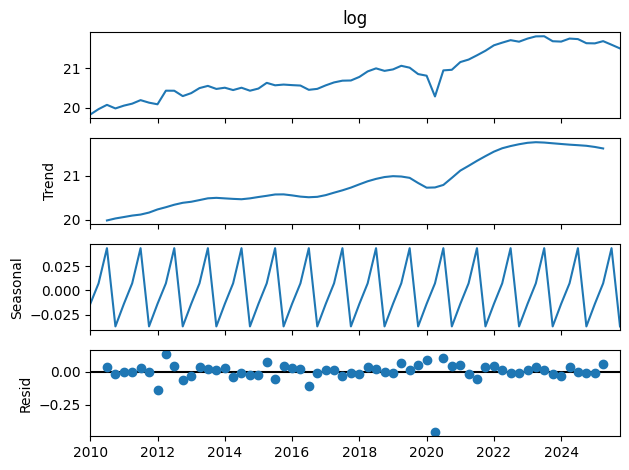

In [25]:
df['log'] = np.log(df['Receitas Líquidas'])

serie = df['log'].copy()
serie.index = serie.index.to_timestamp()

decomp_log = seasonal_decompose(serie, model='addtive', period=4)
decomp_log.plot()
plt.show()

A série de dados Receitas Líquidas, como mostra o gráfico acima, apresenta tendência crescente, clara, com queda em 2020 (Choque estrutural em 2020, com provável presença de outlier). 

O terceiro gráfico mostra a presença de sazonalidade nos dados, com elevação no 4º trimestres e redução no 1º trimestres.

Quanto ao último gráfico, estão próximos de zero, mostrando estabilidade nios resíduos. A exceção é evidenciada em 2020, como o choque estrutural da pandemia.

In [26]:
modelo = SARIMAX(df['log'], order=(0,1,1), seasonal_order=(0,1,1,4), enforce_stationarity=False, enforce_invertibility=False)

result_model = modelo.fit()
print(result_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               log   No. Observations:                   64
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                  26.992
Date:                           Sun, 12 Apr 2026   AIC                            -47.983
Time:                                   22:33:40   BIC                            -42.073
Sample:                               03-31-2010   HQIC                           -45.710
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1887      0.063     -2.986      0.003      -0.313      -0.065
ma.S.L4       -1.0000    947.450     -0.001

Esse modelo tem vários problemas. Primeiro, os resíduos não são normais, dada a elevada curtose. Além disso, tanto MA(4) quanto sigma2 possuem elevado err-padrão e p_value ruim (não passam no teste de hipótese).

In [27]:
modelo2 = SARIMAX(df['log'], order=(1,1,1), seasonal_order=(0,0,1,4), enforce_stationarity=False, enforce_invertibility=False)

result_model2 = modelo2.fit()
print(result_model2.summary())

                                     SARIMAX Results                                     
Dep. Variable:                               log   No. Observations:                   64
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 4)   Log Likelihood                  30.846
Date:                           Sun, 12 Apr 2026   AIC                            -53.692
Time:                                   22:33:44   BIC                            -45.519
Sample:                               03-31-2010   HQIC                           -50.516
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3639      0.482     -0.755      0.450      -1.308       0.581
ma.L1          0.1622      0.486      0.333

Apesar da leve melhora ocorrida, esse modelo tem problemas sérios, ainda.

In [28]:
modelo3 = SARIMAX(df['log'], order=(0,1,1), enforce_stationarity=False, enforce_invertibility=False)

result_model3 = modelo3.fit()
print(result_model3.summary())

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  33.838
Date:                Sun, 12 Apr 2026   AIC                            -63.677
Time:                        22:33:48   BIC                            -59.455
Sample:                    03-31-2010   HQIC                           -62.022
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.1815      0.069     -2.615      0.009      -0.318      -0.045
sigma2         0.0193      0.002      9.228      0.000       0.015       0.023
Ljung-Box (L1) (Q):                   0.25   Jarque-

Esse terceiro modelo tem menores AIC e BIC, o que demonstra melhor ajuste do modelo aos dados, quando comparado aos dois anteriores.

Os coeficientes possuem bons p-values, agora. Ljung-Box indica ausência de autocorrelação.  Heterocedasticidade está ok, também. 

Problema está em Jarque-Bera e, principalmente, na curtose, ainda elevada.

Testar-se-á um novo modelo ARIMA(0,1,1), tal qual o último. Só que agora, com a presença da variável exógena câmbio (PTAX para venda).

In [29]:
modelo4 = SARIMAX(df['log'], exog= df[['cambio']], order=(0,1,1), enforce_stationarity=False, enforce_invertibility=False)

result_model4 = modelo4.fit()
print(result_model4.summary())

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  33.852
Date:                Sun, 12 Apr 2026   AIC                            -61.704
Time:                        22:33:52   BIC                            -55.372
Sample:                    03-31-2010   HQIC                           -59.222
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
cambio        -0.0088      0.063     -0.140      0.889      -0.132       0.114
ma.L1         -0.1845      0.091     -2.034      0.042      -0.362      -0.007
sigma2         0.0193      0.002      7.911      0.0

Como se pode ver, a variável câmbio não se ajusta bem ao modelo, dado que não passa no teste de hipótese, devido ao elevado p-value

Além de ter ocorrido uma piora nos critérios AIC (Akayke) e BIC (Schwartz).

Vamos rodar o modelo3 (ARIMA(0,1,1)), sem transformação logarítmica.

In [ ]:
modelo5 = SARIMAX(df['Receitas Líquidas'], order=(0,1,1), enforce_stationarity=False, enforce_invertibility=False)

result_model5 = modelo5.fit()
print(result_model5.summary())

                               SARIMAX Results                                
Dep. Variable:      Receitas Líquidas   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -1239.223
Date:                Sat, 04 Apr 2026   AIC                           2482.445
Time:                        16:02:43   BIC                           2486.667
Sample:                    03-31-2010   HQIC                          2484.100
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0269      0.088      0.306      0.759      -0.145       0.199
sigma2      2.669e+16   1.61e-18   1.66e+34      0.000    2.67e+16    2.67e+16
Ljung-Box (L1) (Q):                   0.05   Jarque-

AIC/BIC explodiram. Mostram que o modelo transformado em log se ajusta melhor aos dados. Além disso, MA(1) perdeu significância.

Desse modo, o modelo3, ARIMA(0,1,1) é, dentre os modelos, com base nos correlogramas da serie_diff e nos critérios AIC e BIC, além do olhar a heterocedasticidade e Ljung_Box, o que melhor se ajustou aos dados. No entanto, ele possui problemas nos resíduos, que não possuem distribuição normal. Provavelmente, como consequência dos choques estruturais (mormente, a pandemia).

In [30]:
df['dummy_2020'] = (df.index.year == 2020).astype(int)


In [31]:
modelo3_1 = SARIMAX(df['log'], exog=df['dummy_2020'], order=(0,1,1), enforce_stationarity=False, enforce_invertibility=False)
resultado3_1 = modelo3_1.fit()

print(resultado3_1.summary())

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  36.518
Date:                Sun, 12 Apr 2026   AIC                            -67.036
Time:                        22:34:03   BIC                            -60.704
Sample:                    03-31-2010   HQIC                           -64.554
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dummy_2020    -0.2438      0.093     -2.617      0.009      -0.426      -0.061
ma.L1         -0.3238      0.112     -2.894      0.004      -0.543      -0.105
sigma2         0.0177      0.003      5.890      0.0

O modelo3_1 melhora na presença da dummy_2020 (melhores AIC e BIC, sem heterocedasticidade e sem autocorrelação). Mas a distribuição não é normal, pelo teste de Jarque-Bera e pela curtose.

Como deseja-se a previsão dos próximos 4 trimestres e o modelo_3.1 se ajustou bem aos dados. Agora, testa-se a presença de variância condicional através do Teste ARCH.

In [32]:
residuos = resultado3_1.resid.dropna()

In [33]:
teste_arch = het_arch(residuos)
print(teste_arch)

(np.float64(20.846519299279127), np.float64(0.02218958585457951), 2.703789499391873, 0.0114794406424984)


Pelo resultado do Teste ARCH, constata-se a presença de variância condicional nos resíduos. No entanto, os coeficientes passaram nos testes de hipóteses, não há autocorrelação (com base em Ljung-Box). Assim, pode-se usar a média de previsão para os próximos trimestres, mas dado o problema nos resíduos, não se pode fazer uso dos intervalos de confiança para a previsão, os quais serão usados na análise de risco, quando da elaboração do orçamento de caixa.

Assim, tenta-se uma nova solução, com a substituição da dummy_2020, por duas dummies específicas dummy_2020q2 e dummy2020q3.

In [34]:
df['dummy_2020q2'] = (df.index.year == '2020q2').astype(int)
df['dummy_2020q3'] = (df.index.year == '2020q3').astype(int)

In [35]:
modelo3_2 = SARIMAX(df['log'], exog=df[['dummy_2020q2', 'dummy_2020q3']], order=(0,1,1), enforce_stationarity=False, enforce_invertibility=False)
resultado3_2 = modelo3_2.fit()

print(resultado3_1.summary())

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  36.518
Date:                Sun, 12 Apr 2026   AIC                            -67.036
Time:                        22:34:23   BIC                            -60.704
Sample:                    03-31-2010   HQIC                           -64.554
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
dummy_2020    -0.2438      0.093     -2.617      0.009      -0.426      -0.061
ma.L1         -0.3238      0.112     -2.894      0.004      -0.543      -0.105
sigma2         0.0177      0.003      5.890      0.0

Temos rigorosamente os mesmos resultados no modelo3_2 aos encontrados no modelo3_1. Ambos são iguais. Isso reforça que o modelo está bem ajustado, ainda que com problemas nos resíduos, o que nos impede de usar os intervalos de confiança na modelagem do orçamento de caixa, tal qual são apresentados. No entanto, pode-se usá-los como uma base e aumentar os mesmos, na hora de elaborar a análise de risco (análise de sensibilidade e análise de cenários, se for conveniente).

Quanto ao modelo, como dito supra, pode-se usar o modelo3_1 para estimar a previsão de Receitas Líquidas para os próximos 4 trimestres sem problema algum, dado o bom ajuste do modelo.

In [36]:
exog_futuro = pd.DataFrame({'dummy_2020':[0]*4})

forecast_log = resultado3_1.forecast(steps=4, exog=exog_futuro)
forecast_nivel = np.exp(forecast_log)

forecast_nivel


2026Q1    2.269146e+09
2026Q2    2.269146e+09
2026Q3    2.269146e+09
2026Q4    2.269146e+09
Freq: Q-DEC, Name: predicted_mean, dtype: float64

Dado que a previsão ficou igual para todos os 4 trimestres, será incluída no modelo3_2 uma variável de tendência, como forma do modelo captar melhor a tendência presente nos dados. Antes, testar-se-á se a presença da tendência melhorou a explicação do modelo.

In [37]:
modelo3_3 = SARIMAX(df['log'], exog=df['dummy_2020'], order=(0,1,1),trend='c', enforce_stationarity=False, enforce_invertibility=False)
resultado3_3 = modelo3_3.fit()

print(resultado3_3.summary())

                               SARIMAX Results                                
Dep. Variable:                    log   No. Observations:                   64
Model:               SARIMAX(0, 1, 1)   Log Likelihood                  39.530
Date:                Sun, 12 Apr 2026   AIC                            -71.060
Time:                        22:34:35   BIC                            -62.617
Sample:                    03-31-2010   HQIC                           -67.751
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0255      0.011      2.315      0.021       0.004       0.047
dummy_2020    -0.2940      0.099     -2.966      0.003      -0.488      -0.100
ma.L1         -0.4595      0.118     -3.886      0.0

O critério de Akayke (AIC) e o critério de Schwartz (BIC) melhoraram, ambos comparados ao modelo3_1, com a presença da variável tendência (intercept), no modelo3_3. Todos os coeficientes têm p-value significativos. Houve redução na curtose. Além disso, o modelo continua não tendo presença de heterocedasticidade e não tem autocorrelação. Mas, como antes, a distribuição dos resíduos não é normal. 

In [38]:
residuos2 = resultado3_3.resid.dropna()

In [39]:
teste_arch2 = het_arch(residuos2)
print(teste_arch2)

(np.float64(14.745896579771697), np.float64(0.14160428928973906), 1.6153051469351205, 0.13468825875985696)


O modelo3_3, com a presença de intercepto como tendência, não indica presença de heterocedasticidade condicional nos resíduos. Ou seja, o único problema do modelo é que os resíduos não seguem a distribuição normal. Assim, pode-se usar os intervalos de confiança para a previsão dos 4 trimestres.

In [40]:
exog_futuro1 = pd.DataFrame({'dummy_2020':[0]*4})

forecast_log1 = resultado3_3.forecast(steps=4, exog=exog_futuro1)
forecast_nivel1 = np.exp(forecast_log1)

forecast_nivel1


2026Q1    2.428666e+09
2026Q2    2.491448e+09
2026Q3    2.555854e+09
2026Q4    2.621924e+09
Freq: Q-DEC, Name: predicted_mean, dtype: float64

In [43]:
forecast_log1_1 = resultado3_3.get_forecast(steps=4, exog=exog_futuro1)
conf_int_log = forecast_log1_1.conf_int()

conf_int_nivel = np.exp(conf_int_log)
conf_int_nivel.columns=['lower', 'upper']
conf_int_nivel

,lower,upper
2026Q1,1.895296e+09,3.112137e+09
2026Q2,1.879488e+09,3.302663e+09
2026Q3,1.870647e+09,3.492049e+09
2026Q4,1.866845e+09,3.682408e+09


In [46]:
conf_int_nivel.to_excel('interv_confianca.xlsx')